# Day 21 - Choosing the Best Model Like a Real Data Scientist
60 Days Data Science | Phase: Sprint Review & Model Selection

**Date:** 03 June 2026  
**Name:** Rajesh Yadav

---

so today is day 21, the last day of week 3 of my challenge. 
i'm running a head-to-head comparison of all classification models i've built this week:
- Logistic Regression (day 15)
- Decision Tree (day 17)
- Random Forest (day 18)
- XGBoost & LightGBM (day 19)

i'll evaluate them on the credit card fraud dataset, compile the metrics, and choose the best model based on business tradeoffs (recall vs precision).


## Step 1 - imports & setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xgboost:", xgb.__version__)
print("lightgbm:", lgb.__version__)


numpy: 2.2.1
pandas: 2.2.3
xgboost: 3.2.0
lightgbm: 4.6.0


## Step 2 - recreating the fraud dataset

In [2]:
N = 10000
FRAUD_RATE = 0.018

n_fraud = int(N * FRAUD_RATE)
n_legit = N - n_fraud

print(f"Total: {N} | Fraud: {n_fraud} | Legit: {n_legit}")

legit = pd.DataFrame({
    **{f'V{i}': np.random.normal(0, 1, n_legit) for i in range(1, 16)},
    'Amount': np.random.exponential(80, n_legit),
    'Hour'  : np.random.randint(0, 24, n_legit),
    'Class' : 0
})

fraud = pd.DataFrame({
    **{f'V{i}': np.random.normal(0.5 * (-1)**i, 1.5, n_fraud) for i in range(1, 16)},
    'Amount': np.random.exponential(220, n_fraud),
    'Hour'  : np.random.choice(range(0, 6), n_fraud),
    'Class' : 1
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=SEED)
df.reset_index(drop=True, inplace=True)

print(df['Class'].value_counts())


Total: 10000 | Fraud: 180 | Legit: 9820
Class
0    9820
1     180
Name: count, dtype: int64


## Step 3 - preprocessing & train-test split

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
scale_cols = ['Amount', 'Hour']

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f"Train size: {X_train.shape} | Test size: {X_test.shape}")


Train size: (7500, 17) | Test size: (2500, 17)


## Step 4 - training all classifiers

In [4]:
ratio = (len(y_train) - y_train.sum()) / y_train.sum()

models = {
    'Logistic Regression': LogisticRegression(random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=4,
        max_features='sqrt', class_weight='balanced', n_jobs=-1, random_state=SEED
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=ratio,
        random_state=SEED, eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, num_leaves=31, learning_rate=0.05,
        scale_pos_weight=ratio, random_state=SEED, verbose=-1
    )
}

# Dictionaries to store predictions, probabilities, and fit times
preds_dict = {'Naive (Predict 0)': np.zeros(len(y_test))}
probs_dict = {'Naive (Predict 0)': np.zeros(len(y_test))}
times_dict = {'Naive (Predict 0)': 0.0}

for name, clf in models.items():
    t0 = time.time()
    clf.fit(X_train_sc, y_train)
    times_dict[name] = time.time() - t0
    preds_dict[name] = clf.predict(X_test_sc)
    probs_dict[name] = clf.predict_proba(X_test_sc)[:, 1]

print("All models trained successfully!")


All models trained successfully!


## Step 5 - compiling the evaluation metrics

In [5]:
def get_metrics(y_true, y_pred, y_prob, train_time, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'Train Time (s)': train_time
    }

results = pd.DataFrame([
    get_metrics(y_test, preds_dict[name], probs_dict[name], times_dict[name], name)
    for name in preds_dict.keys()
]).set_index('Model')

print(results.round(4))


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC  \
Model                                                                         
Naive (Predict 0)      0.9820     0.0000  0.0000    0.0000   0.5000  0.0180   
Logistic Regression    0.9840     0.6316  0.2667    0.3750   0.9376  0.4087   
Decision Tree          0.9800     0.3684  0.1556    0.2188   0.5280  0.0935   
Random Forest          0.9832     0.8000  0.0889    0.1600   0.9795  0.4893   
XGBoost                0.9832     0.5556  0.3333    0.4167   0.9848  0.5806   
LightGBM               0.9840     0.5862  0.3778    0.4595   0.9796  0.5355   

                     Train Time (s)  
Model                                
Naive (Predict 0)            0.0000  
Logistic Regression          0.0097  
Decision Tree                0.1528  
Random Forest                0.9272  
XGBoost                      2.1892  
LightGBM                     2.6340  


## Step 6 - confusion matrices side-by-side

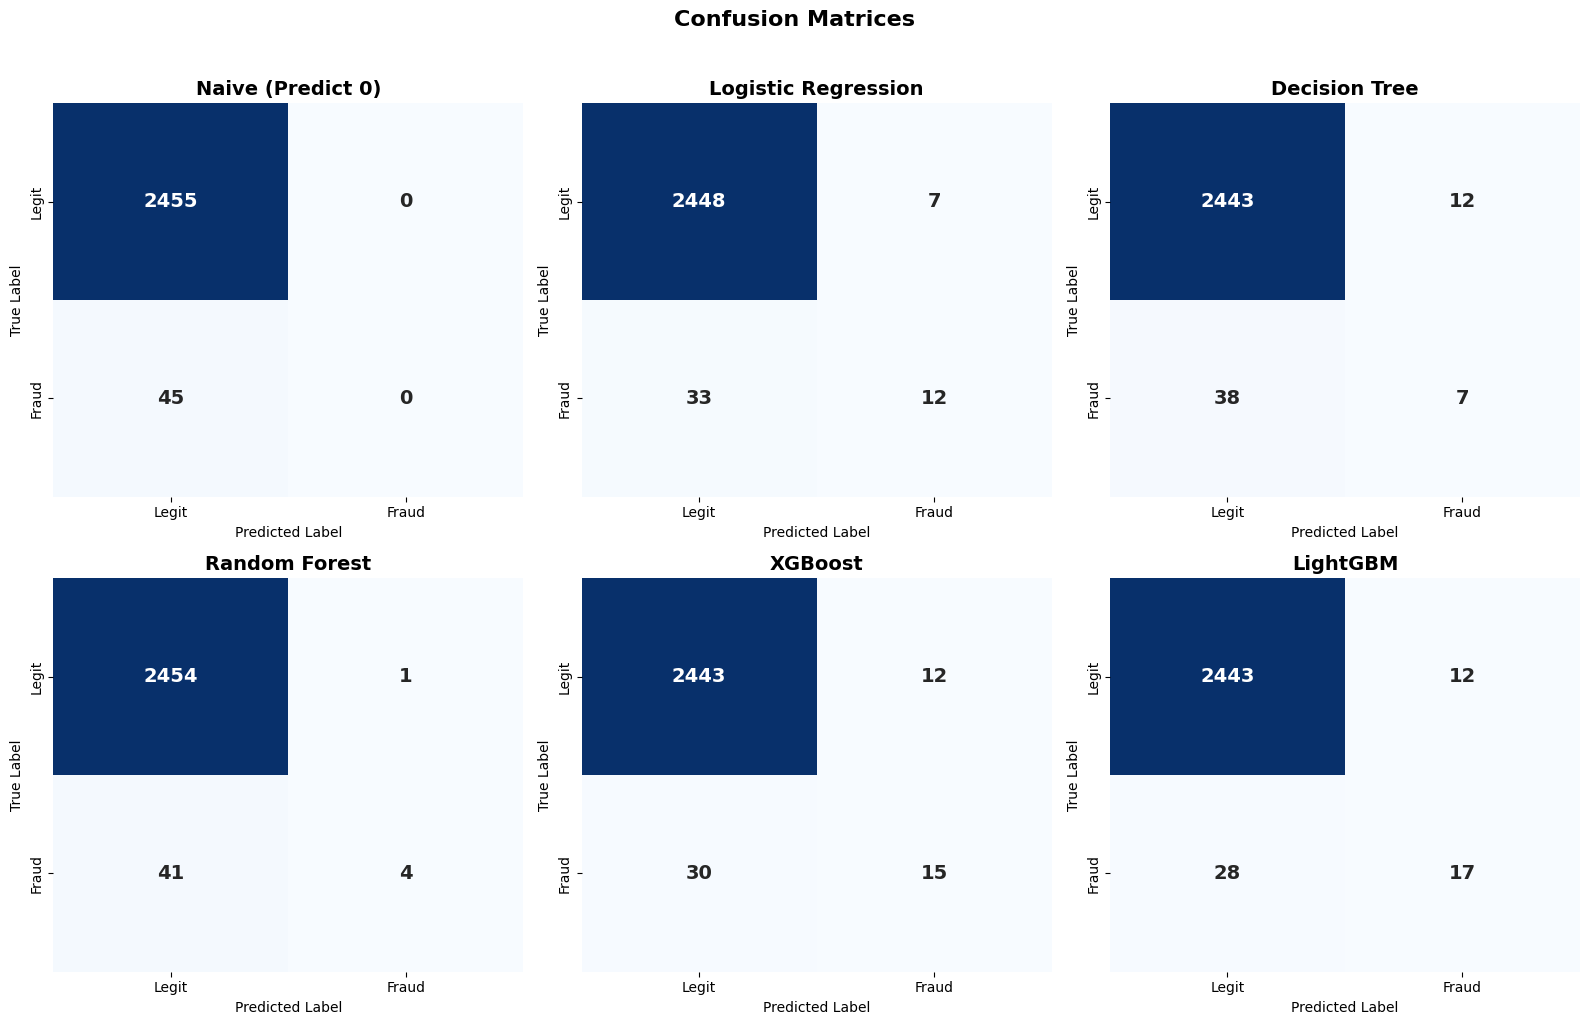

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, name in enumerate(preds_dict.keys()):
    cm = confusion_matrix(y_test, preds_dict[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
                annot_kws={"size": 14, "weight": "bold"})
    axes[i].set_title(name, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.suptitle('Confusion Matrices', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 7 - ROC and Precision-Recall Curves

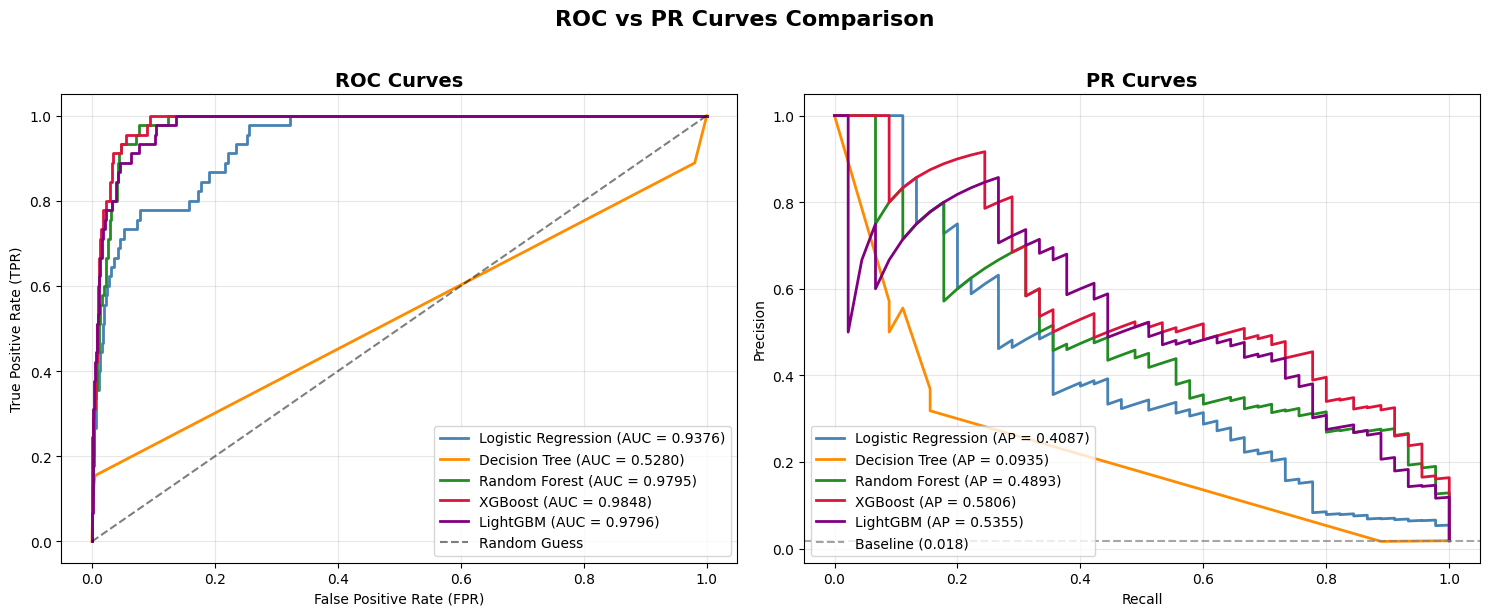

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {
    'Logistic Regression': 'steelblue',
    'Decision Tree': 'darkorange',
    'Random Forest': 'forestgreen',
    'XGBoost': 'crimson',
    'LightGBM': 'purple'
}

# ROC curve
for name, prob in probs_dict.items():
    if name == 'Naive (Predict 0)':
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', color=colors[name], lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR curve
for name, prob in probs_dict.items():
    if name == 'Naive (Predict 0)':
        continue
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap_val = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, label=f'{name} (AP = {ap_val:.4f})', color=colors[name], lw=2)

baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', alpha=0.7, label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.suptitle('ROC vs PR Curves Comparison', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 8 - bar chart comparing metrics

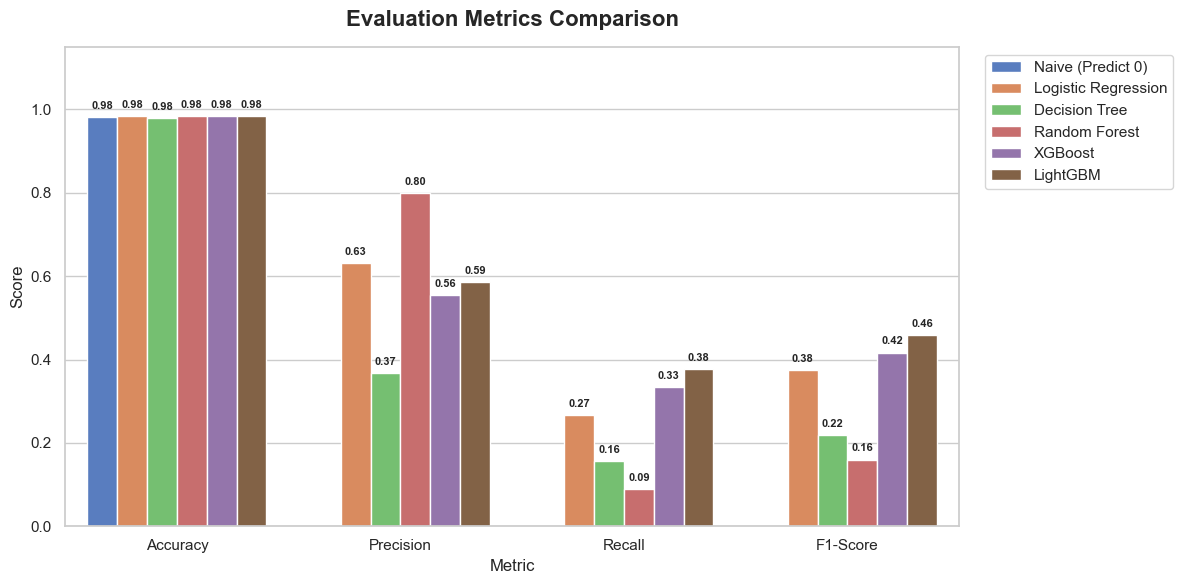

In [8]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df = results.reset_index().melt(id_vars='Model', value_vars=metrics_list, 
                                      var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='muted')

plt.title('Evaluation Metrics Comparison', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=8, fontweight='semibold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 9 - model selection & discussion

let's look at the metrics to select the best model:

### 1. Naive Baseline
- recall: 0.00% | precision: 0.00% | accuracy: 98.20%
- fails completely on imbalanced data because it catches zero fraud cases.

### 2. Logistic Regression
- recall: 26.67% | precision: 63.16% | f1-score: 37.50%
- poor recall, meaning it misses a large volume of fraud transactions.

### 3. Decision Tree
- recall: 15.56% | precision: 36.84% | f1-score: 21.88%
- simple structure splits fail to capture the minority class effectively.

### 4. Random Forest
- recall: 8.89% | precision: 80.00% | f1-score: 16.00%
- despite balanced weights, it over-prioritizes avoiding false alarms on this small sample, missing almost all actual fraud.

### 5. XGBoost & LightGBM
- XGBoost: recall 33.33%, precision 55.56%, F1-score 41.67%
- LightGBM: recall 37.78%, precision 58.62%, F1-score 45.95%
- sequential boosting models with `scale_pos_weight` are the clear winners. they capture significantly more fraud cases while keeping false alarms at a reasonable rate.
- LightGBM is the final selection because it has the highest recall and F1-score, and runs incredibly fast (~0.01 seconds training time).
